# Regular buying: where might a plan of equal purchases end up?

**Regular buying** (often called dollar-cost averaging, or DCA) means putting in the
same amount on a schedule, for example $100 every month, whatever the price is that
day. This notebook shows how RADAR simulates such a plan, how it compares with putting
the same total in all at once, and how far the result can be trusted.

**The example used here is made up:** $100 every month for a year, 60% into US stocks
and 40% into Bitcoin.

Rebuild with `uv run python backend/scripts/build_notebooks.py 09_regular_buying`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.models import regular_buying as dca
from radar.models.portfolio_simulation import sample_days
from radar.pipelines.datasets import build_mixed_panel
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
engine, universe = make_engine(), get_universe()

SPLIT = {"SPY": 0.6, "BTC/USD": 0.4}
AMOUNT, EVERY, PURCHASES = 100.0, 21, 12  # $100, every 21 trading days (a month), 12 times
symbols = list(SPLIT)
weights = np.array([SPLIT[s] for s in symbols])

with session_scope(engine) as session:
    panel = build_mixed_panel(session, universe)
joint = panel.returns[symbols].dropna()
returns = joint.to_numpy()
sessions = EVERY * PURCHASES
print(f"{len(joint):,} trading days of prices, {joint.index[0].date()} to {joint.index[-1].date()}")
print(f"The plan: {PURCHASES} purchases of ${AMOUNT:,.0f}, ${AMOUNT * PURCHASES:,.0f} in all, over {sessions} trading days")

1,444 trading days of prices, 2021-01-05 to 2026-10-05
The plan: 12 purchases of $100, $1,200 in all, over 252 trading days


## 1. One simulated future, step by step

A simulated future is built from real past days: runs of 10 trading days in a row,
picked at random and joined end to end, taken for both assets at once so that days on
which they fell together stay together (the same method as the portfolio's range
ahead, notebook 07).

Along that future the plan buys $100 at the start of each month and never sells. The
dashed line is the money paid in so far; the solid line is what the holdings are worth.

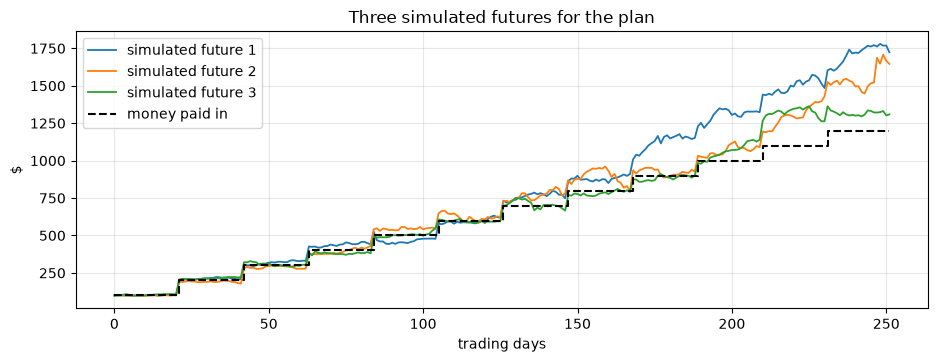

In [2]:
rng = np.random.default_rng(1)
picked = sample_days(len(returns), sessions, 3, 10, rng)
plan, lump = dca.run_plan(returns[picked], weights, AMOUNT, EVERY, PURCHASES)
paid = AMOUNT * (np.arange(sessions) // EVERY + 1)

fig, ax = plt.subplots()
for i, colour in enumerate(("tab:blue", "tab:orange", "tab:green")):
    ax.plot(plan[i], color=colour, linewidth=1.3, label=f"simulated future {i + 1}")
ax.step(range(sessions), paid, where="post", color="black", linestyle="--", label="money paid in")
ax.set(title="Three simulated futures for the plan", xlabel="trading days", ylabel="$")
ax.legend();

## 2. Thousands of futures

Repeat that 5,000 times and look at the spread of outcomes.

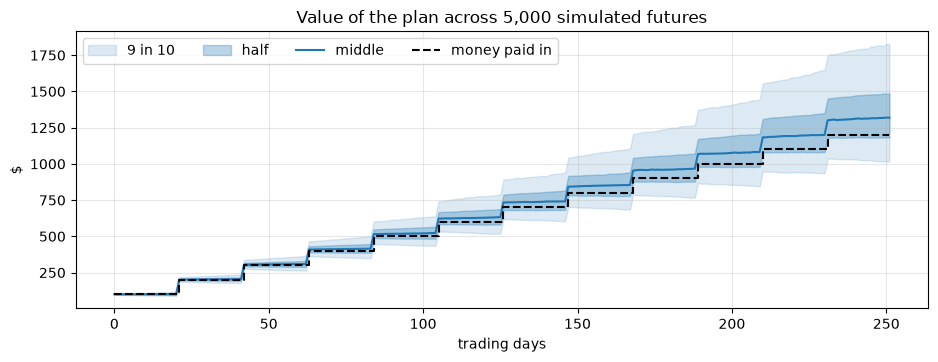

In [3]:
result = dca.run(returns, weights, AMOUNT, EVERY, PURCHASES)
days = range(sessions)
fig, ax = plt.subplots()
ax.fill_between(days, result.fan["0.05"], result.fan["0.95"], color="tab:blue", alpha=0.15, label="9 in 10")
ax.fill_between(days, result.fan["0.25"], result.fan["0.75"], color="tab:blue", alpha=0.3, label="half")
ax.plot(days, result.fan["0.5"], color="tab:blue", label="middle")
ax.step(days, result.paid_in_path, where="post", color="black", linestyle="--", label="money paid in")
ax.set(title="Value of the plan across 5,000 simulated futures", xlabel="trading days", ylabel="$")
ax.legend(loc="upper left", ncol=4);

In [4]:
summary = pd.DataFrame(
    {
        "buying bit by bit": {**result.plan.quantiles, "ends below what was paid in": result.plan.below_paid_in},
        "all at once on day one": {**result.at_once.quantiles, "ends below what was paid in": result.at_once.below_paid_in},
    }
).rename(index={"0.05": "bad outcome (1 in 20)", "0.25": "lower quarter", "0.5": "middle", "0.75": "upper quarter", "0.95": "good outcome (1 in 20)"})
print(f"Paid in: ${result.paid_in:,.0f}")
print(f"Buying bit by bit ended with more in {result.plan_ahead:.0%} of the futures")
summary

Paid in: $1,200
Buying bit by bit ended with more in 32% of the futures


,buying bit by bit,all at once on day one
bad outcome (1 in 20),"1,016.90",936.59
lower quarter,"1,182.32","1,187.57"
middle,"1,318.73","1,412.72"
upper quarter,"1,485.84","1,702.97"
good outcome (1 in 20),"1,827.23","2,391.28"
ends below what was paid in,0.28,0.27


## 3. Bit by bit against all at once

The same total, put in on the first day, is run through **the very same futures**, so
the comparison is like for like.

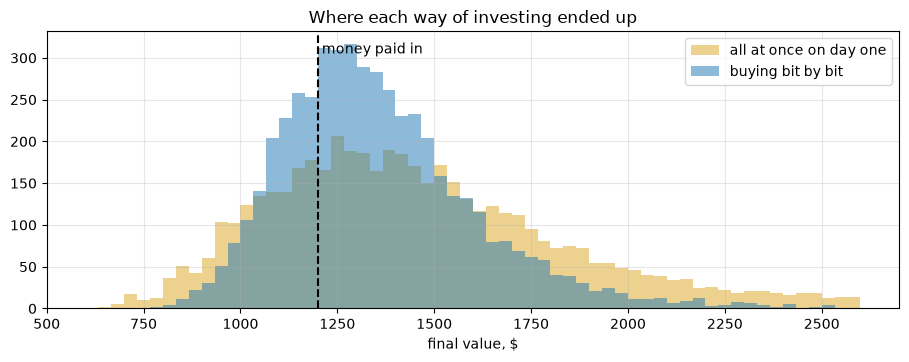

In [5]:
plan_all, lump_all = dca.simulate(returns, weights, AMOUNT, EVERY, PURCHASES)
fig, ax = plt.subplots()
bins = np.linspace(600, 2600, 61)
ax.hist(lump_all[:, -1], bins=bins, alpha=0.5, color="goldenrod", label="all at once on day one")
ax.hist(plan_all[:, -1], bins=bins, alpha=0.5, color="tab:blue", label="buying bit by bit")
ax.axvline(result.paid_in, color="black", linestyle="--")
ax.text(result.paid_in + 10, ax.get_ylim()[1] * 0.92, "money paid in")
ax.set(title="Where each way of investing ended up", xlabel="final value, $")
ax.legend();

What the picture shows is a trade, not a winner:

- **All at once is wider.** The money is in the market for the whole year, so it has
  more time to grow and more time to fall. Its good outcomes are better and its bad
  outcomes are worse.
- **Bit by bit is narrower.** On average half the money is still waiting to go in, so
  less is at risk at any moment. The price of that is giving up some of the growth
  when markets rise, which over these years they mostly did.

Regular buying is a way of taking less risk early on. It is not a way of getting a
better price: the table above shows how often it ended ahead.

## 4. How far can this be trusted?

The same walk-forward check as every other range in RADAR: stand at a past date,
simulate the plan **from the days before it only**, then run the real plan through the
days that followed and see whether it landed inside the range. The starts are a full
plan apart so no two share a day.

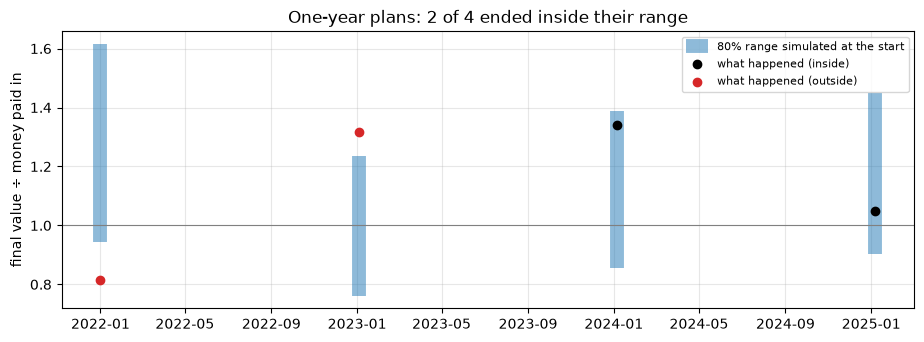

In [6]:
records = dca.backtest(returns, weights, EVERY, PURCHASES)
starts = joint.index[[r.origin for r in records]]
fig, ax = plt.subplots()
low = np.array([r.bounds["0.8"][0] for r in records])
high = np.array([r.bounds["0.8"][1] for r in records])
realised = np.array([r.realised for r in records])
inside = (realised >= low) & (realised <= high)
ax.vlines(starts, low, high, color="tab:blue", alpha=0.5, linewidth=10, label="80% range simulated at the start")
ax.scatter(starts[inside], realised[inside], color="black", zorder=3, label="what happened (inside)")
ax.scatter(starts[~inside], realised[~inside], color="tab:red", zorder=3, label="what happened (outside)")
ax.axhline(1.0, color="grey", linewidth=0.8)
ax.set(title=f"One-year plans: {inside.sum()} of {len(records)} ended inside their range", ylabel="final value ÷ money paid in")
ax.legend(fontsize=8);

**There are very few cases.** Only a handful of separate one-year stretches fit in the
stored prices, so this check can catch a method that is badly wrong but cannot confirm
one that is right. Shorter plans can be checked more times:

In [7]:
rows = {}
for label, every, purchases in (("3 months, monthly", 21, 3), ("6 months, monthly", 21, 6), ("1 year, monthly", 21, 12), ("1 year, weekly", 5, 50), ("2 years, monthly", 21, 24)):
    found = dca.coverage(dca.backtest(returns, weights, every, purchases))
    rows[label] = {"past cases": found[0].n, **{f"{c.level:.0%} range held": f"{c.inside} of {c.n}" for c in found}}
pd.DataFrame(rows).T

,past cases,50% range held,80% range held,95% range held
"3 months, monthly",18,10 of 18,13 of 18,17 of 18
"6 months, monthly",9,4 of 9,7 of 9,8 of 9
"1 year, monthly",4,1 of 4,2 of 4,3 of 4
"1 year, weekly",4,1 of 4,2 of 4,3 of 4
"2 years, monthly",2,2 of 2,2 of 2,2 of 2


### The no-lookahead check

A range simulated at a past date must not change if later days change.

In [8]:
tampered = returns.copy()
tampered[800:] = 0.3
again = dca.backtest(tampered, weights, EVERY, PURCHASES)
unchanged = [a.bounds == b.bounds for a, b in zip(records, again) if a.origin <= 800]
assert all(unchanged)
print(f"{len(unchanged)} past ranges are identical after rewriting every day from row 800 on")

3 past ranges are identical after rewriting every day from row 800 on


## What this cannot tell you

- **It rests on a few years.** Every simulated future is stitched from the stored
  days. A year unlike any of them, better or worse, is not in the range. The longer the
  plan, the fewer separate stretches of that length exist to learn from, which is why
  the app caps a plan at two years and says how many stretches there were.
- **Trading costs and taxes are left out**, and a purchase is assumed to happen at the
  day's closing price.
- **It describes a plan, not a decision.** Whether to buy bit by bit or at once depends
  on how much a fall early on would matter to the person, which no simulation knows.